In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline


In [ ]:
df=pd.read_csv('wustliot.csv')

In [ ]:
df

,Dir,Flgs,SrcAddr,DstAddr,Sport,Dport,SrcBytes,DstBytes,SrcLoad,DstLoad,...,Temp,SpO2,Pulse_Rate,SYS,DIA,Heart_rate,Resp_Rate,ST,Attack Category,Label
0,->,e,10.0.1.172,10.0.1.150,58059,1111,496,186,276914.0,92305.0,...,28.9,0,0,0,0,0,0,0.0,normal,0
1,->,e,10.0.1.172,10.0.1.150,58062,1111,496,186,230984.0,76995.0,...,28.9,0,0,0,0,78,17,0.4,normal,0
2,->,e,10.0.1.172,10.0.1.150,58065,1111,496,186,218470.0,72823.0,...,28.9,89,104,0,0,78,17,0.4,normal,0
3,->,e,10.0.1.172,10.0.1.150,58067,1111,496,186,203376.0,67792.0,...,28.9,89,104,0,0,79,17,0.4,normal,0
4,->,e,10.0.1.172,10.0.1.150,58069,1111,496,186,235723.0,78574.0,...,28.9,89,101,0,0,79,17,0.4,normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16313,->,e,10.0.1.172,10.0.1.150,57348,1111,496,186,205128.0,68376.0,...,27.7,98,73,148,84,73,19,0.3,normal,0
16314,->,e,10.0.1.172,10.0.1.150,63265,1111,496,186,274058.0,91353.0,...,27.7,98,73,148,84,73,19,0.3,normal,0
16315,->,e,10.0.1.172,10.0.1.150,63918,1111,496,186,288568.0,96189.0,...,23.6,98,73,148,84,73,19,0.3,normal,0
16316,->,e,10.0.1.172,10.0.1.150,52345,1111,496,186,237795.0,79265.0,...,27.4,98,73,148,84,73,19,0.3,normal,0


In [ ]:
df.drop(columns=['Label','Dir','Flgs'], inplace=True)


**# Save the training and testing sets to separate CSV files**

In [ ]:
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

In [ ]:
categorical_features

['SrcAddr', 'DstAddr', 'Sport', 'SrcMac', 'DstMac', 'Attack Category']

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16318 entries, 0 to 16317
Data columns (total 42 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   SrcAddr          16318 non-null  object 
 1   DstAddr          16318 non-null  object 
 2   Sport            16318 non-null  object 
 3   Dport            16318 non-null  int64  
 4   SrcBytes         16318 non-null  int64  
 5   DstBytes         16318 non-null  int64  
 6   SrcLoad          16318 non-null  float64
 7   DstLoad          16318 non-null  float64
 8   SrcGap           16318 non-null  int64  
 9   DstGap           16318 non-null  int64  
 10  SIntPkt          16318 non-null  float64
 11  DIntPkt          16318 non-null  float64
 12  SIntPktAct       16318 non-null  float64
 13  DIntPktAct       16318 non-null  int64  
 14  SrcJitter        16318 non-null  float64
 15  DstJitter        16318 non-null  float64
 16  sMaxPktSz        16318 non-null  int64  
 17  dMaxPktSz   

In [ ]:
from sklearn.preprocessing import LabelEncoder


cols_to_encode = ['SrcAddr', 'DstAddr', 'Sport', 'SrcMac', 'DstMac']


le = LabelEncoder()
for col in cols_to_encode:
    if col in df.columns:
        df[col] = le.fit_transform(df[col].astype(str))

print("✅ Encoding complete for:", cols_to_encode)


✅ Encoding complete for: ['SrcAddr', 'DstAddr', 'Sport', 'SrcMac', 'DstMac']


In [ ]:
attack_counts = df['Attack Category'].value_counts()


print(attack_counts)


Attack Category
normal             14272
Spoofing            1124
Data Alteration      922
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Attack Category'] = df['Attack Category'].astype(str)
df['Attack Category'] = le.fit_transform(df['Attack Category'])


mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("✅ 'Attack Category' label encoding mapping:")
for label, code in mapping.items():
    print(f"{label} --> {code}")


✅ 'Attack Category' label encoding mapping:
Data Alteration --> 0
Spoofing --> 1
normal --> 2


In [ ]:
attack_counts = df['Attack Category'].value_counts()


print(attack_counts)


Attack Category
2    14272
1     1124
0      922
Name: count, dtype: int64


In [ ]:
df.describe()

,SrcAddr,DstAddr,Sport,Dport,SrcBytes,DstBytes,SrcLoad,DstLoad,SrcGap,DstGap,...,Packet_num,Temp,SpO2,Pulse_Rate,SYS,DIA,Heart_rate,Resp_Rate,ST,Attack Category
count,16318.0,16318.0,16318.000000,16318.0,16318.000000,16318.000000,1.631800e+04,1.631800e+04,16318.0,16318.0,...,16318.000000,16318.000000,16318.000000,16318.000000,16318.000000,16318.000000,16318.000000,16318.000000,16318.000000,16318.000000
mean,0.0,0.0,8156.157434,1111.0,496.650264,187.077706,2.118406e+05,7.102435e+04,0.0,0.0,...,8156.308800,26.906815,97.808861,76.723741,142.846611,80.094190,75.443927,19.695551,0.258007,1.818115
std,0.0,0.0,4709.841490,0.0,28.584642,18.688525,7.942988e+04,4.530811e+04,0.0,0.0,...,4709.735634,0.919766,1.496269,7.431914,8.493933,6.125289,6.609102,7.325856,0.103980,0.511686
min,0.0,0.0,0.000000,1111.0,310.000000,120.000000,0.000000e+00,5.074470e+02,0.0,0.0,...,1.000000,23.600000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.300000,0.000000
25%,0.0,0.0,4077.250000,1111.0,496.000000,186.000000,1.990535e+05,6.635500e+04,0.0,0.0,...,4077.250000,26.600000,98.000000,73.000000,142.000000,76.000000,73.000000,18.000000,0.200000,2.000000
50%,0.0,0.0,8156.500000,1111.0,496.000000,186.000000,2.366790e+05,7.889300e+04,0.0,0.0,...,8156.500000,27.000000,98.000000,73.000000,144.000000,83.000000,73.000000,19.000000,0.300000,2.000000
75%,0.0,0.0,12234.750000,1111.0,496.000000,186.000000,2.615570e+05,8.719300e+04,0.0,0.0,...,12234.750000,27.600000,98.000000,79.000000,148.000000,84.000000,79.000000,24.000000,0.300000,2.000000
max,0.0,0.0,16313.000000,1111.0,2298.000000,882.000000,1.134000e+06,3.938000e+06,0.0,0.0,...,16314.000000,29.200000,100.000000,194.000000,149.000000,95.000000,119.000000,73.000000,1.000000,2.000000


In [ ]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns


numeric_cols = [col for col in numeric_cols if col != 'Attack Category']

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    mean_value = df[col].mean()

    df[col] = df[col].apply(lambda x: mean_value if (x < lower_bound or x > upper_bound) else x)


In [ ]:
from sklearn.feature_selection import chi2
from sklearn.feature_selection import SelectKBest
import pandas as pd


target_col = 'Attack Category'


X = df.drop(columns=[target_col])
y = df[target_col]


chi_scores, p_values = chi2(X, y)


alpha = 0.05
significant_features = X.columns[p_values < alpha]
insignificant_features = X.columns[p_values >= alpha]

df.drop(columns=insignificant_features, inplace=True)


print("✅ Significant Features (kept in df):")
print(list(significant_features))

print("\n❌ Insignificant Features (removed):")
print(list(insignificant_features))


✅ Significant Features (kept in df):
['Sport', 'SrcLoad', 'DstLoad', 'SIntPkt', 'DIntPkt', 'SrcJitter', 'DstJitter', 'Dur', 'Load', 'Rate', 'SrcMac', 'Packet_num', 'Pulse_Rate', 'SYS', 'Heart_rate', 'Resp_Rate']

❌ Insignificant Features (removed):
['Dport', 'SrcBytes', 'DstBytes', 'SIntPktAct', 'sMaxPktSz', 'dMaxPktSz', 'sMinPktSz', 'dMinPktSz', 'Trans', 'TotPkts', 'TotBytes', 'Loss', 'pLoss', 'pSrcLoss', 'pDstLoss', 'Temp', 'SpO2', 'DIA', 'ST']


In [ ]:
df.shape

(16318, 23)

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr


df = df.dropna()


target_col = 'Attack Category'
features = df.drop(columns=[target_col]).columns


results = []


for feature in features:
    corr, p_value = pearsonr(df[feature], df[target_col])
    results.append({'feature': feature, 'correlation': corr, 'p_value': p_value})


results_df = pd.DataFrame(results)


alpha = 0.05
n_tests = len(results_df)
corrected_alpha = alpha / n_tests

significant_df = results_df[results_df['p_value'] < corrected_alpha]


significant_df['abs_corr'] = significant_df['correlation'].abs()
top_10_features = significant_df.sort_values(by='abs_corr', ascending=False).head(10)

print("Top 10 features (Bonferroni-corrected):")
print(top_10_features[['feature', 'correlation', 'p_value']])


Top 10 features (Bonferroni-corrected):
      feature  correlation        p_value
15     SrcMac    -0.938850   0.000000e+00
11  DstJitter    -0.586827   0.000000e+00
8     DIntPkt    -0.584797   0.000000e+00
12        Dur    -0.458437   0.000000e+00
7     SIntPkt    -0.457026   0.000000e+00
10  SrcJitter    -0.254530  1.211605e-239
3     SrcLoad     0.187802  2.018824e-129
13       Load     0.186485  1.312221e-127
14       Rate     0.184373  9.928717e-125
4     DstLoad     0.182493  3.385632e-122


/tmp/ipython-input-97-2653995595.py:17: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_value = pearsonr(df[feature], df[target_col])
/tmp/ipython-input-97-2653995595.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  significant_df['abs_corr'] = significant_df['correlation'].abs()


In [ ]:

selected_features = [
    'SrcMac', 'DstJitter', 'DIntPkt', 'Dur', 'SIntPkt',
    'SrcJitter', 'SrcLoad', 'Load', 'Rate', 'DstLoad'
]


selected_features.append('Attack Category')


df_selected = df[selected_features]


print(df_selected.shape)
print(df_selected.head())


(16318, 11)
   SrcMac  DstJitter  DIntPkt       Dur   SIntPkt  SrcJitter   SrcLoad  \
0     0.0     1.6235   1.9015  0.010747  3.582333   2.946239  276914.0   
1     0.0     2.8625   2.9015  0.012884  4.294667   3.091654  230984.0   
2     0.0     3.1655   3.2945  0.013622  4.540667   2.849841  218470.0   
3     0.0     3.2570   3.3320  0.014633  4.877667   2.452252  203376.0   
4     0.0     2.8225   2.8635  0.012625  4.208333   3.021835  235723.0   

       Load     Rate  DstLoad  Attack Category  
0  369219.0  558.295  92305.0                2  
1  307979.0  465.694  76995.0                2  
2  291293.0  440.464  72823.0                2  
3  271168.0  410.032  67792.0                2  
4  314297.0  475.247  78574.0                2  


In [ ]:
from sklearn.model_selection import train_test_split


train_df, test_df = train_test_split(df_selected, test_size=0.2, random_state=42)




In [ ]:
train_df

,SrcMac,DstJitter,DIntPkt,Dur,SIntPkt,SrcJitter,SrcLoad,Load,Rate,DstLoad,Attack Category
2477,0.000000,8.546796,8.515423,0.016607,5.535667,32.025841,179202.000000,238935.000000,361.29300,59734.00000,2
13455,0.000000,2.359000,2.377000,0.012656,4.218667,3.276737,235145.000000,313527.000000,474.08300,78382.00000,2
13152,0.000000,4.021000,4.063000,0.014894,4.964667,3.540479,199812.000000,266416.000000,402.84700,66604.00000,2
8544,0.000000,3.030000,3.089000,0.013139,4.379667,3.111506,226501.000000,302002.000000,456.65600,75500.00000,2
11117,0.000000,2.767500,2.785500,0.013493,4.497667,3.340153,220559.000000,294078.000000,444.67500,73520.00000,2
...,...,...,...,...,...,...,...,...,...,...,...
13418,0.000000,1.845000,1.852000,0.010507,3.502333,2.810188,283240.000000,377653.000000,571.04800,94413.00000,2
5390,0.000000,8.546796,8.515423,0.039227,10.946755,32.025841,211840.633005,282864.995695,428.72025,71024.35494,2
860,0.000000,2.116500,2.176500,0.011331,3.777000,2.901826,262642.000000,350190.000000,529.52100,87547.00000,2
15795,0.125383,8.546796,8.515423,0.039227,10.946755,3.259362,211840.633005,282864.995695,428.72025,71024.35494,0


In [ ]:
# Show counts in train set
print("Train set Attack type counts:")
print(train_df['Attack Category'].value_counts())

print("\nTest set Attack type counts:")
print(test_df['Attack Category'].value_counts())


Train set Attack type counts:
Attack Category
2    11424
1      895
0      735
Name: count, dtype: int64

Test set Attack type counts:
Attack Category
2    2848
1     229
0     187
Name: count, dtype: int64


In [ ]:
from sklearn.utils import resample


df_majority = train_df[train_df['Attack Category'] == 2]
df_minority_1 = train_df[train_df['Attack Category'] == 1]
df_minority_0 = train_df[train_df['Attack Category'] == 0]


df_minority_1_upsampled = resample(
    df_minority_1,
    replace=True,
    n_samples=len(df_majority),
    random_state=42
)


df_minority_0_upsampled = resample(
    df_minority_0,
    replace=True,
    n_samples=len(df_majority),
    random_state=42
)


train_df_balanced = pd.concat([df_majority, df_minority_1_upsampled, df_minority_0_upsampled])


train_df_balanced = train_df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# Display class distribution
print(train_df_balanced['Attack Category'].value_counts())


Attack Category
2    11424
1    11424
0    11424
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()

feature_cols = train_df_balanced.columns.drop('Attack Category')


train_df_balanced[feature_cols] = scaler.fit_transform(train_df_balanced[feature_cols])
test_df[feature_cols] = scaler.transform(test_df[feature_cols])

print("✅ Standardization done in-place on:")
print(f"- train_df_balanced: {train_df_balanced.shape}")
print(f"- test_df: {test_df.shape}")


✅ Standardization done in-place on:
- train_df_balanced: (34272, 11)
- test_df: (3264, 11)


In [ ]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 7.5 MB/s eta 0:00:00


In [ ]:
import time
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier


X_balanced = train_df_balanced.drop(columns=['Attack Category'])
y_balanced = train_df_balanced['Attack Category']


noise_std_fraction = 0.15
X_noisy = X_balanced.copy()

for col in X_noisy.columns:
    std = X_noisy[col].std()
    noise = np.random.normal(0, noise_std_fraction * std, size=X_noisy[col].shape)
    X_noisy[col] += noise


classifiers = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_split=4, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=10, min_samples_split=4, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5, weights='uniform'),
    "MLP": MLPClassifier(hidden_layer_sizes=(128,), max_iter=1000, alpha=0.001, solver='adam', random_state=42),
    "CatBoost": CatBoostClassifier(iterations=500, learning_rate=0.1, depth=6, l2_leaf_reg=10, random_state=42, verbose=0)
}


for clf_name, clf in classifiers.items():
    print(f"\nTraining {clf_name} on Noisy Data...")

    # Measure training time
    start_time = time.time()
    clf.fit(X_noisy, y_balanced)
    end_time = time.time()

    # Predict on training data
    y_train_pred = clf.predict(X_noisy)

    # Print classification report and training time
    print(f"\n{clf_name} Training Classification Report (Noisy Data):")
    print(classification_report(y_balanced, y_train_pred, digits=4))
    print(f"Training Time: {end_time - start_time:.4f} seconds")



Training Random Forest on Noisy Data...

Random Forest Training Classification Report (Noisy Data):
              precision    recall  f1-score   support

           0     0.9700    1.0000    0.9848     11424
           1     1.0000    0.9691    0.9843     11424
           2     1.0000    1.0000    1.0000     11424

    accuracy                         0.9897     34272
   macro avg     0.9900    0.9897    0.9897     34272
weighted avg     0.9900    0.9897    0.9897     34272

Training Time: 14.4014 seconds

Training Decision Tree on Noisy Data...

Decision Tree Training Classification Report (Noisy Data):
              precision    recall  f1-score   support

           0     0.9710    0.9998    0.9852     11424
           1     0.9998    0.9702    0.9848     11424
           2     1.0000    1.0000    1.0000     11424

    accuracy                         0.9900     34272
   macro avg     0.9903    0.9900    0.9900     34272
weighted avg     0.9903    0.9900    0.9900     34272

Train


===== Random Forest on Noisy Test Data =====
Classification Report:
              precision    recall  f1-score   support

           0     0.9842    1.0000    0.9920       187
           1     1.0000    0.9869    0.9934       229
           2     1.0000    1.0000    1.0000      2848

    accuracy                         0.9991      3264
   macro avg     0.9947    0.9956    0.9951      3264
weighted avg     0.9991    0.9991    0.9991      3264



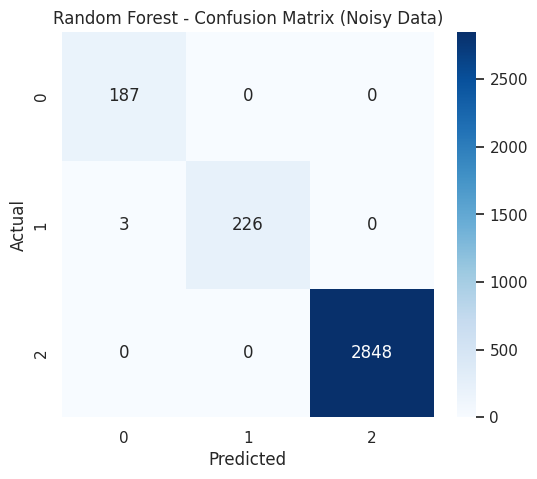

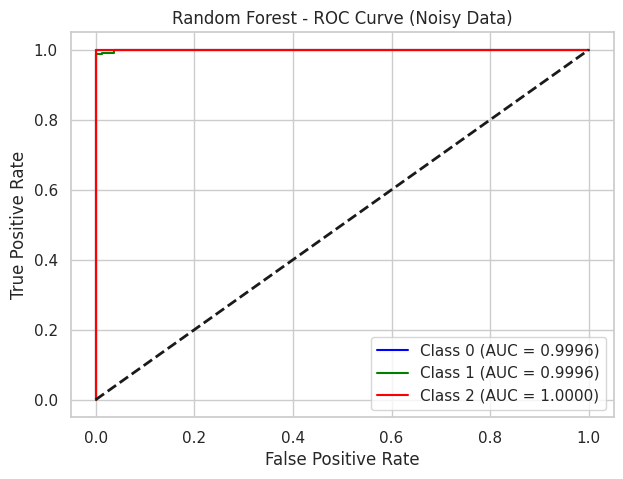

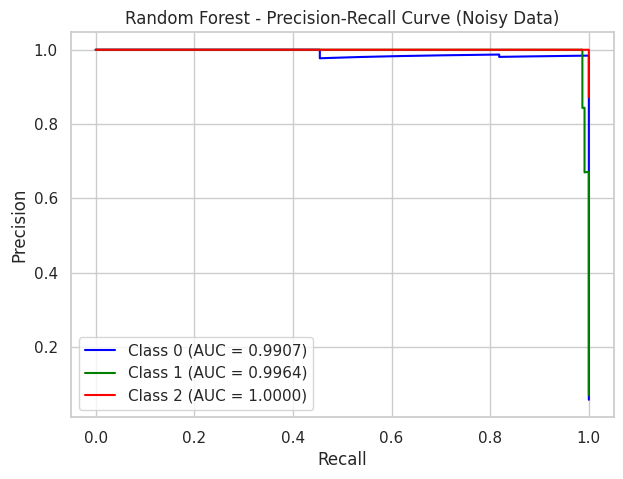

Inference Time: 0.1838 seconds

===== Decision Tree on Noisy Test Data =====
Classification Report:
              precision    recall  f1-score   support

           0     0.9842    1.0000    0.9920       187
           1     1.0000    0.9869    0.9934       229
           2     1.0000    1.0000    1.0000      2848

    accuracy                         0.9991      3264
   macro avg     0.9947    0.9956    0.9951      3264
weighted avg     0.9991    0.9991    0.9991      3264



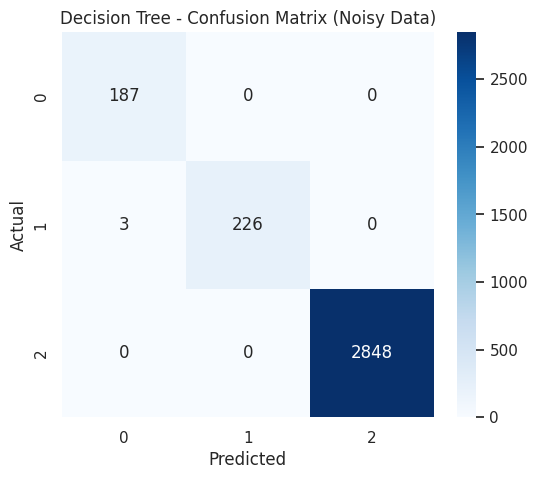

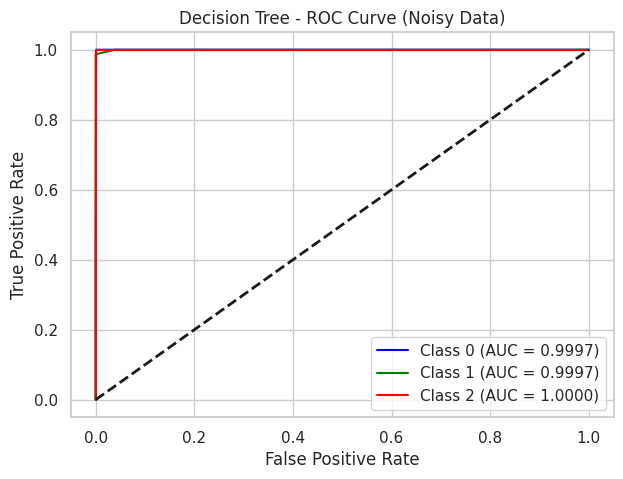

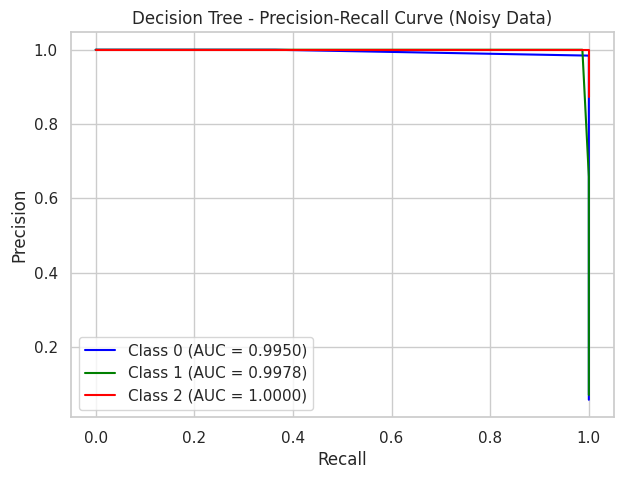

Inference Time: 0.0118 seconds

===== KNN on Noisy Test Data =====
Classification Report:
              precision    recall  f1-score   support

           0     0.9842    1.0000    0.9920       187
           1     1.0000    0.9869    0.9934       229
           2     1.0000    1.0000    1.0000      2848

    accuracy                         0.9991      3264
   macro avg     0.9947    0.9956    0.9951      3264
weighted avg     0.9991    0.9991    0.9991      3264



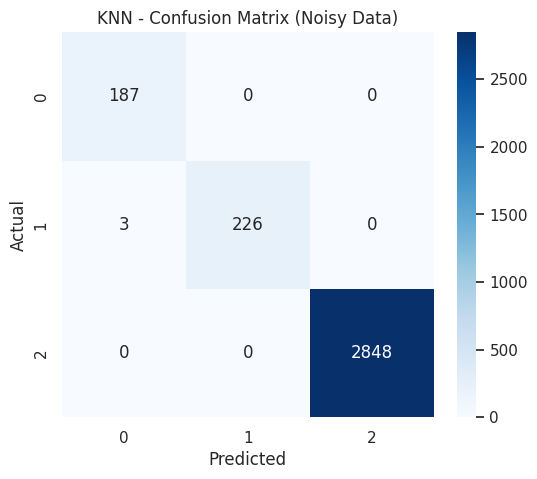

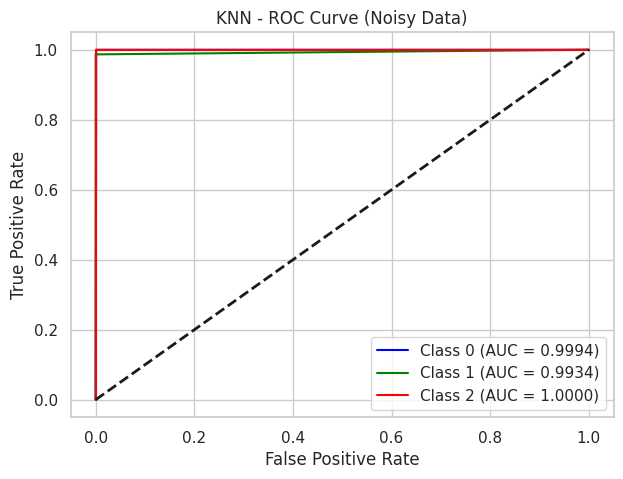

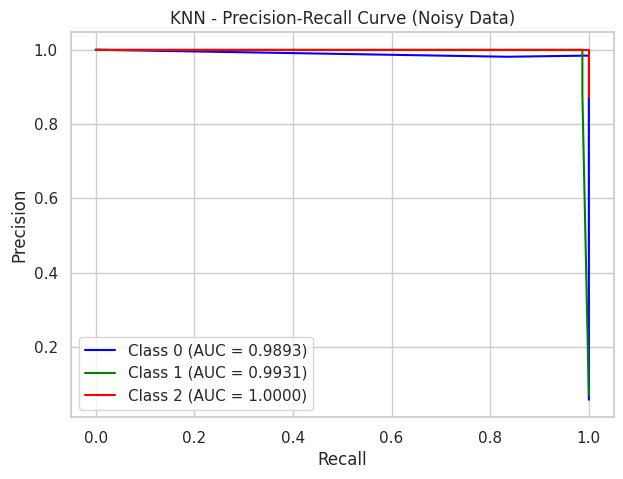

Inference Time: 2.3490 seconds

===== MLP on Noisy Test Data =====
Classification Report:
              precision    recall  f1-score   support

           0     0.9842    1.0000    0.9920       187
           1     1.0000    0.9869    0.9934       229
           2     1.0000    1.0000    1.0000      2848

    accuracy                         0.9991      3264
   macro avg     0.9947    0.9956    0.9951      3264
weighted avg     0.9991    0.9991    0.9991      3264



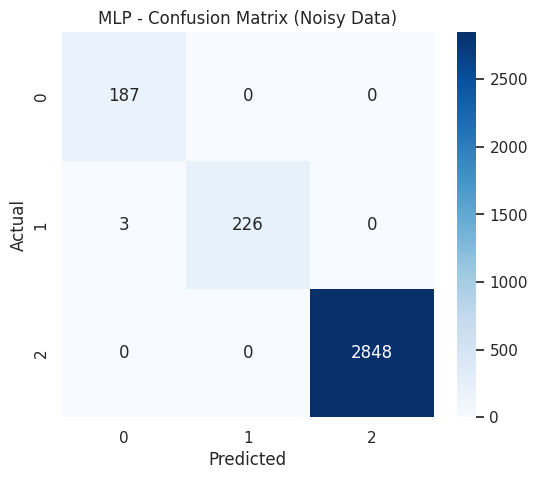

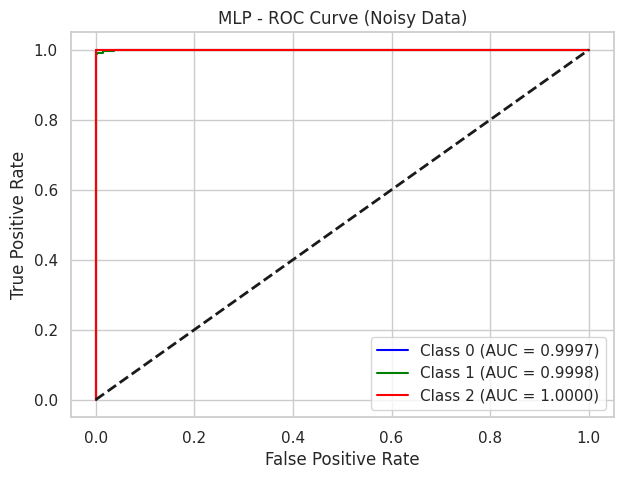

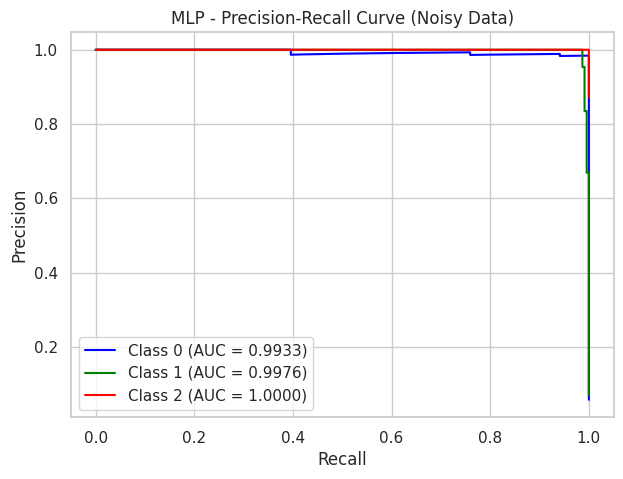

Inference Time: 0.0973 seconds

===== CatBoost on Noisy Test Data =====
Classification Report:
              precision    recall  f1-score   support

           0     0.9842    1.0000    0.9920       187
           1     0.9912    0.9825    0.9868       229
           2     0.9996    0.9993    0.9995      2848

    accuracy                         0.9982      3264
   macro avg     0.9917    0.9939    0.9928      3264
weighted avg     0.9982    0.9982    0.9982      3264



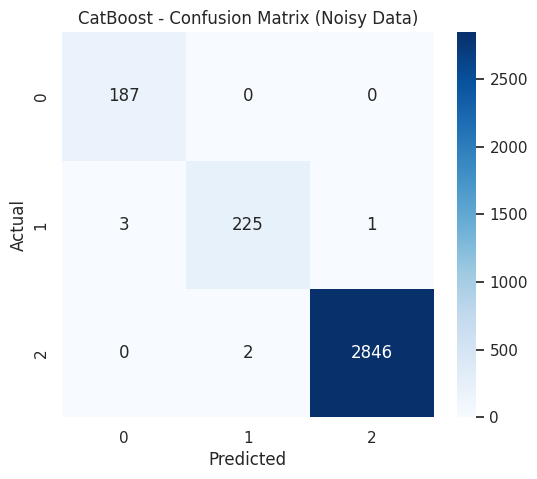

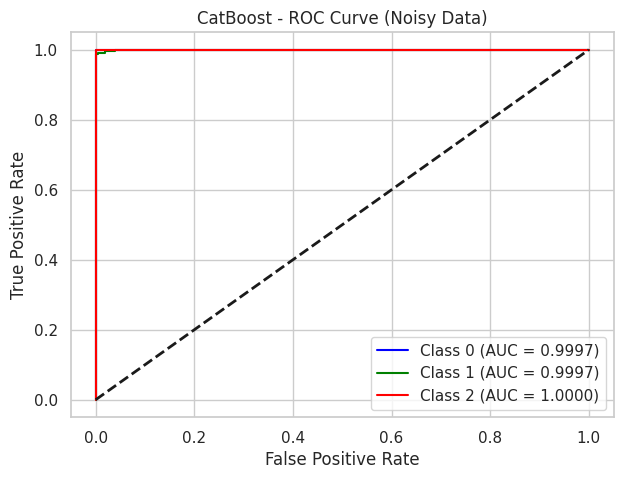

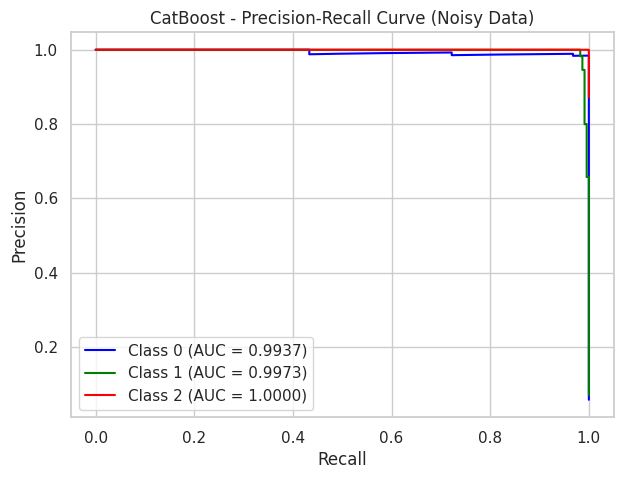

Inference Time: 0.0639 seconds


In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
)

features = [
    'SrcMac', 'DstJitter', 'DIntPkt', 'Dur', 'SIntPkt',
    'SrcJitter', 'SrcLoad', 'Load', 'Rate', 'DstLoad'
]

/
X_test = test_df[features]
y_test = test_df['Attack Category']
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

noise_std_fraction = 0.15
feature_stds = X_balanced[features].std()
noise_std = noise_std_fraction * feature_stds

# Inject noise into test data
X_test_noisy = X_test.copy()
for col in features:
    noise = np.random.normal(0, noise_std[col], size=X_test_noisy.shape[0])
    X_test_noisy[col] += noise

# Plot style
sns.set(style='whitegrid')
colors = ['blue', 'green', 'red']

def evaluate_and_plot(clf_name, clf, X_eval, y_true, y_true_bin, noisy=False):
    noise_tag = "Noisy" if noisy else "Clean"
    print(f"\n===== {clf_name} on {noise_tag} Test Data =====")

    # Inference and timing
    start_time = time.time()
    y_pred = clf.predict(X_eval)
    y_proba = clf.predict_proba(X_eval)
    end_time = time.time()
    inference_time = end_time - start_time

    # Classification Report
    print("Classification Report:")
    print(classification_report(y_true, y_pred, digits=4))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1,2], yticklabels=[0,1,2])
    plt.title(f"{clf_name} - Confusion Matrix ({noise_tag} Data)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # ROC Curve (one-vs-rest)
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(3):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    plt.figure(figsize=(7, 5))
    for i in range(3):
        plt.plot(fpr[i], tpr[i], color=colors[i], label=f"Class {i} (AUC = {roc_auc[i]:.4f})")
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.title(f"{clf_name} - ROC Curve ({noise_tag} Data)")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.grid(True)
    plt.show()

    # PR Curve
    precision = dict()
    recall = dict()
    pr_auc = dict()
    for i in range(3):
        precision[i], recall[i], _ = precision_recall_curve(y_true_bin[:, i], y_proba[:, i])
        pr_auc[i] = auc(recall[i], precision[i])

    plt.figure(figsize=(7, 5))
    for i in range(3):
        plt.plot(recall[i], precision[i], color=colors[i], label=f"Class {i} (AUC = {pr_auc[i]:.4f})")
    plt.title(f"{clf_name} - Precision-Recall Curve ({noise_tag} Data)")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()
    plt.grid(True)
    plt.show()

    print(f"Inference Time: {inference_time:.4f} seconds")


# Evaluate all classifiers on noisy test data only
for clf_name, clf in classifiers.items():
    evaluate_and_plot(clf_name, clf, X_test_noisy, y_test, y_test_bin, noisy=True)


In [ ]:
from sklearn.metrics import cohen_kappa_score

for clf_name, clf in classifiers.items():
    y_pred = clf.predict(X_test)
    kappa = cohen_kappa_score(y_test, y_pred)
    print(f"{clf_name} Cohen's Kappa Score: {kappa:.4f}")


Random Forest Cohen's Kappa Score: 0.9960
Decision Tree Cohen's Kappa Score: 0.9947
Extra Trees Cohen's Kappa Score: 0.9960
KNN Cohen's Kappa Score: 0.9960
MLP Cohen's Kappa Score: 0.9960
CatBoost Cohen's Kappa Score: 0.9960
XGBoost Cohen's Kappa Score: 0.9960


In [ ]:
from sklearn.metrics import accuracy_score

for clf_name, clf in classifiers.items():
    y_pred = clf.predict(X_test_noisy)
    acc = accuracy_score(y_test, y_pred)
    print(f"{clf_name} Accuracy on noisy test data: {acc:.4f}")


Random Forest Accuracy on noisy test data: 0.9991
Decision Tree Accuracy on noisy test data: 0.9991
KNN Accuracy on noisy test data: 0.9991
MLP Accuracy on noisy test data: 0.9991
CatBoost Accuracy on noisy test data: 0.9982


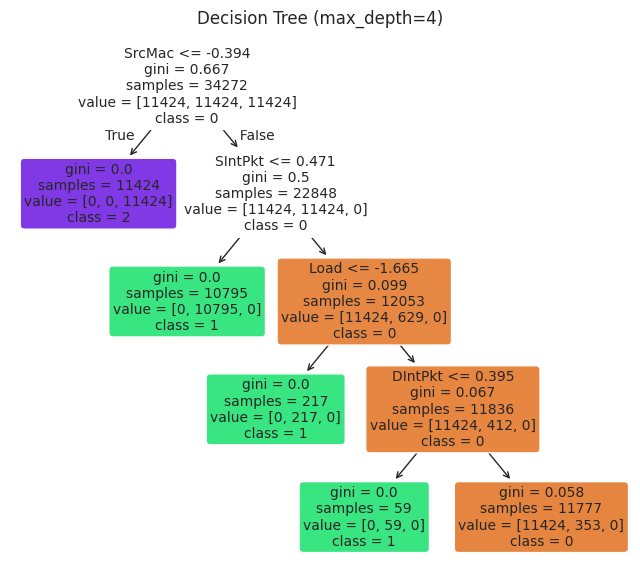

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt


dt_clf = DecisionTreeClassifier(max_depth=4, min_samples_split=4, random_state=42)
dt_clf.fit(X_noisy, y_balanced)


plt.figure(figsize=(8, 7))
plot_tree(dt_clf,
          feature_names=X_noisy.columns,
          class_names=[str(c) for c in dt_clf.classes_],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Decision Tree (max_depth=4)")
plt.show()


In [ ]:
pip install shap


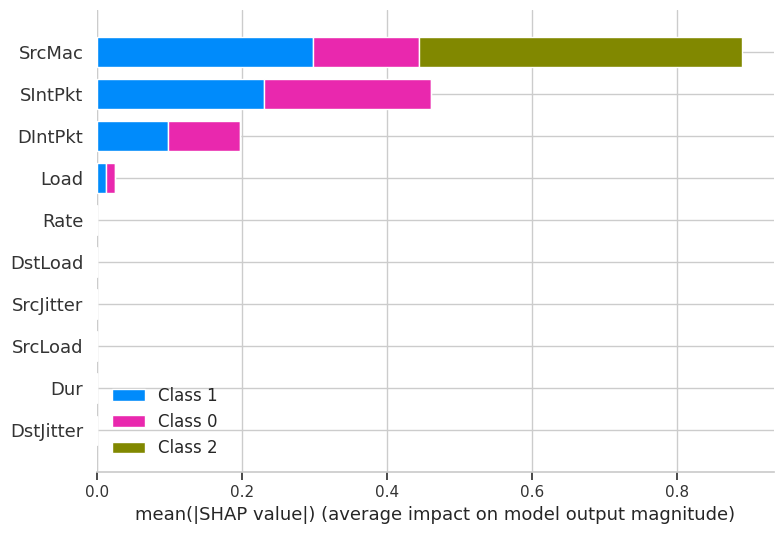

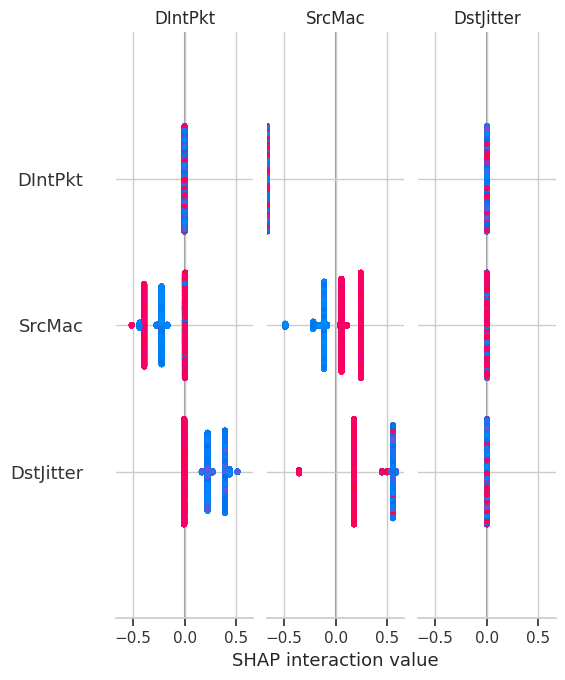

DimensionError: Length of features is not equal to the length of shap_values!

In [ ]:
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(dt_clf)


shap_values = explainer.shap_values(X_noisy)

shap.summary_plot(shap_values, X_noisy, plot_type="bar")


shap.summary_plot(shap_values, X_noisy)

shap.initjs()
shap.force_plot(explainer.expected_value[1], shap_values[1][0], X_noisy.iloc[0,:])


In [ ]:
pip install SALib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 778.9/778.9 kB 11.8 MB/s eta 0:00:00


                 mu   mu_star     sigma  mu_star_conf
SrcMac     1.063488  1.063488  0.702851      0.428436
DstJitter  0.000000  0.000000  0.000000      0.000000
DIntPkt   -0.145504  0.145504  0.460124      0.260981
Dur        0.000000  0.000000  0.000000      0.000000
SIntPkt   -0.145504  0.145504  0.460124      0.280770
SrcJitter  0.000000  0.000000  0.000000      0.000000
SrcLoad    0.000000  0.000000  0.000000      0.000000
Load       0.000000  0.000000  0.000000      0.000000
Rate       0.000000  0.000000  0.000000      0.000000
DstLoad    0.000000  0.000000  0.000000      0.000000


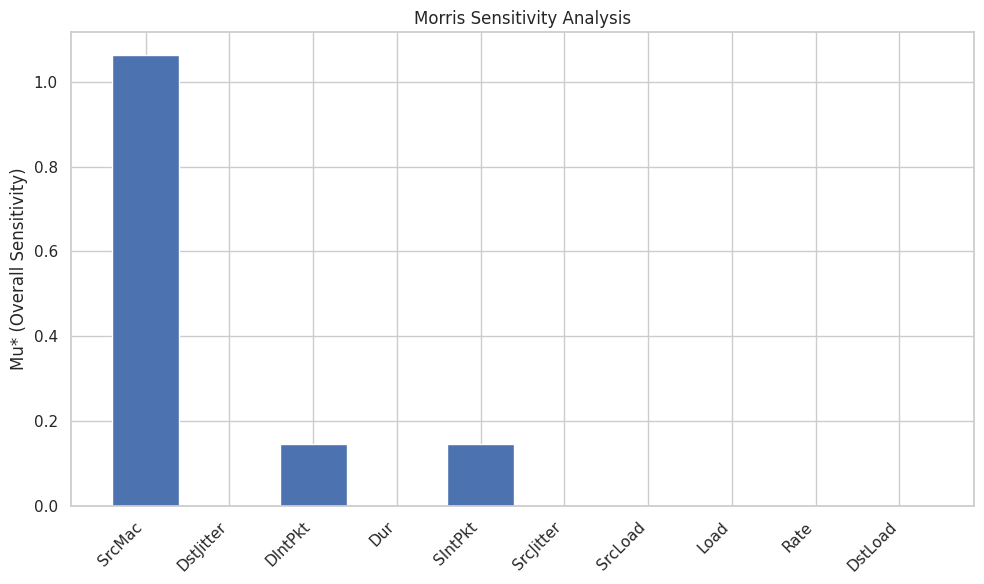

In [ ]:
from SALib.sample import morris as morris_sample
from SALib.analyze import morris as morris_analyze
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


problem = {
    'num_vars': X_noisy.shape[1],
    'names': list(X_noisy.columns),
    'bounds': [[X_noisy[col].min(), X_noisy[col].max()] for col in X_noisy.columns]
}


param_values = morris_sample.sample(problem, N=1000, num_levels=4, optimal_trajectories=10)


def model_predict(X):
    df = pd.DataFrame(X, columns=problem['names'])
    preds = dt_clf.predict_proba(df)
 
    return preds[:, 1]

Y = model_predict(param_values)

morris_results = morris_analyze.analyze(problem, param_values, Y,
                                       conf_level=0.95, print_to_console=True, num_levels=4)

# Plot mu_star (overall sensitivity)
plt.figure(figsize=(10,6))
plt.bar(problem['names'], morris_results['mu_star'])
plt.ylabel('Mu* (Overall Sensitivity)')
plt.title('Morris Sensitivity Analysis')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


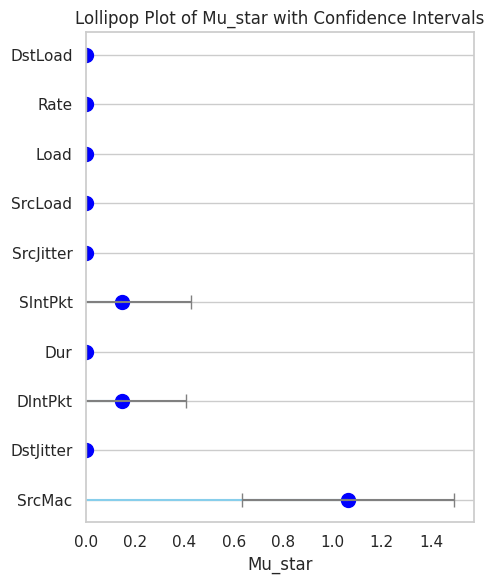

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

data = {
    'Feature': ['SrcMac', 'DstJitter', 'DIntPkt', 'Dur', 'SIntPkt', 'SrcJitter', 'SrcLoad', 'Load', 'Rate', 'DstLoad'],
    'mu_star': [1.063488, 0.0, 0.145504, 0.0, 0.145504, 0.0, 0.0, 0.0, 0.0, 0.0],
    'mu_star_conf': [0.428436, 0.0, 0.260981, 0.0, 0.280770, 0.0, 0.0, 0.0, 0.0, 0.0]
}
df = pd.DataFrame(data)

plt.figure(figsize=(5,6))
plt.hlines(y=df['Feature'], xmin=0, xmax=df['mu_star'], color='skyblue')
plt.scatter(df['mu_star'], df['Feature'], color='blue', s=100)

# Add error bars manually (horizontal)
for idx, row in df.iterrows():
    plt.errorbar(x=row['mu_star'], y=row['Feature'], xerr=row['mu_star_conf'], fmt='none', ecolor='gray', capsize=5)

plt.xlabel('Mu_star')
plt.title('Lollipop Plot of Mu_star with Confidence Intervals')
plt.xlim(left=0)
plt.grid(axis='x')
plt.tight_layout()
plt.show()


In [ ]:
import time
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from catboost import CatBoostClassifier

# Prepare features and labels
X_balanced = train_df_balanced.drop(columns=['Attack Category'])
y_balanced = train_df_balanced['Attack Category']

# Step 1: Add Gaussian Noise
noise_std_fraction = 0.15
X_noisy = X_balanced.copy()
for col in X_noisy.columns:
    std = X_noisy[col].std()
    noise = np.random.normal(0, noise_std_fraction * std, size=X_noisy[col].shape)
    X_noisy[col] += noise

# Step 2: Define Classifiers
classifiers = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_split=4, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=10, min_samples_split=4, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "MLP": MLPClassifier(hidden_layer_sizes=(128,), max_iter=1000, alpha=0.001, solver='adam', random_state=42),
    "CatBoost": CatBoostClassifier(iterations=500, learning_rate=0.1, depth=6, l2_leaf_reg=10, random_state=42, verbose=0)
}

# Step 3: 5-Fold CV Evaluation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in classifiers.items():
    print(f"\nClassifier: {name}")
    start_time = time.time()
    scores = cross_val_score(model, X_noisy, y_balanced, cv=cv, scoring='accuracy')
    end_time = time.time()

    for i, score in enumerate(scores, 1):
        print(f"  Fold {i}: Accuracy = {score:.4f}")

    print(f"Mean CV Accuracy: {scores.mean():.4f}")
    print(f"Standard Deviation: {scores.std():.4f}")
    print(f"Total CV Time: {end_time - start_time:.2f} seconds")



Classifier: Random Forest
  Fold 1: Accuracy = 0.9910
  Fold 2: Accuracy = 0.9896
  Fold 3: Accuracy = 0.9883
  Fold 4: Accuracy = 0.9892
  Fold 5: Accuracy = 0.9902
Mean CV Accuracy: 0.9897
Standard Deviation: 0.0009
Total CV Time: 36.79 seconds

Classifier: Decision Tree
  Fold 1: Accuracy = 0.9904
  Fold 2: Accuracy = 0.9885
  Fold 3: Accuracy = 0.9872
  Fold 4: Accuracy = 0.9891
  Fold 5: Accuracy = 0.9896
Mean CV Accuracy: 0.9889
Standard Deviation: 0.0011
Total CV Time: 1.20 seconds

Classifier: KNN
  Fold 1: Accuracy = 0.9908
  Fold 2: Accuracy = 0.9895
  Fold 3: Accuracy = 0.9883
  Fold 4: Accuracy = 0.9892
  Fold 5: Accuracy = 0.9902
Mean CV Accuracy: 0.9896
Standard Deviation: 0.0009
Total CV Time: 6.03 seconds

Classifier: MLP
  Fold 1: Accuracy = 0.9910
  Fold 2: Accuracy = 0.9896
  Fold 3: Accuracy = 0.9883
  Fold 4: Accuracy = 0.9893
  Fold 5: Accuracy = 0.9902
Mean CV Accuracy: 0.9897
Standard Deviation: 0.0009
Total CV Time: 26.30 seconds

Classifier: CatBoost
  Fold 1